In [1]:
# Written for python 3.10.12
# UTF8-encoding
#
# Author: Niels S Hvidberg
# Date: 02-06-2024
# 
# Description: Importing and organising ICOS measuring stations
# as preparation for easy data extraction in DEHM output files.

## Import libraries, often used libraries are included but commented out
import numpy as np
import matplotlib.pyplot as plt
import icoscp

import seaborn as sb
# import numpy as np
import pandas as pd
# import xarray as xr
import datetime as dt

sb.set_theme()

In [2]:
## stations dictionary:
#
# Number of stations: 38
nstat = 38
# Number of data files: 91
nfile = 91
#
# Description:
# Name: Name of station.
# Code: Short 3 character code for the station.
# Height_ordered: List of measuring heights ordered by station.
# Height: List of measuring heights.
# Country: Country code for the location.
# Measurements: 
# File: File name for the stations data files.
# STR: 3 string components that wraps 'Code' and 'Height'.
#      'ICOS_ATC_L2_L2-2023.1_{stations['Code'][i]}_{stations['Height'][i][j]}_CTS_CO2'
# Path: The path to the Data directory for the ICOS stations data.
#
stations = {'Name': ['Kresin',
                     'Station Nord',
                     'Pallas',
                     'Puijo',
                     'Hyytiala',
                     'Uto',
                     'Observatoire Perenne',
                     'Puy de Dome',
                     'La Reunion',
                     'Saclay',
                     'Trainou',
                     'Gartow',
                     'Helgoland',
                     'Hohenpeissenberg',
                     'Julich',
                     'Karlsruhe',
                     'Lindenberg',
                     'Ochsenkopf',
                     'Schauinsland',
                     'Steinkimmen',
                     'Torfhaus',
                     'Westerland',
                     'Zugspitze',
                     'Monte Cimone',
                     'Ispra',
                     'Lampedusa',
                     'Plateau Rosa',
                     'Cabauw',
                     'Lutjewad',
                     'Birkenes',
                     'Zeppelin',
                     'Izana',
                     'Hyltemossa',
                     'Norunda',
                     'Svartberget',
                     'Jungfraujoch',
                     'Ridge Hill',
                     'Weybourne',
                ],

            'Code': ['KRE',
                     'SNO',
                     'PAL',
                     'PUI',
                     'SMR',
                     'UTO',
                     'OPE',
                     'PUY',
                     'RUN',
                     'SAC',
                     'TRN',
                     'GAT',
                     'HEL',
                     'HPB',
                     'JUE',
                     'KIT',
                     'LIN',
                     'OXK',
                     'SSL',
                     'STE',
                     'TOH',
                     'WES',
                     'ZSF',
                     'CMN',
                     'IPR',
                     'LMP',
                     'PRS',
                     'CBW',
                     'LUT',
                     'BIR',
                     'ZEP',
                     'IZO',
                     'HTM',
                     'NOR',
                     'SVB',
                     'JFJ',
                     'RGL',
                     'WAO',
                ],

            'Height_ordered': [[10.0, 50.0, 125.0, 250.0],
                       	       [20.0, 50.0, 85.0],
                       	       [12.0],
                       	       [47.0,84.0],
                       	       [16.8, 67.2, 125.0],
                       	       [57.0],
                       	       [10.0, 50.0, 120.0],
                       	       [10.0],
                       	       [6.0],
                       	       [15.0, 60.0, 100.0],
                       	       [5.0, 50.0, 100.0, 180.0],
                       	       [30.0, 60.0, 132.0, 216.0, 341.0],
                       	       [110.0],
                       	       [50.0, 93.0, 131.0],
                       	       [50.0, 80.0, 120.0],
                       	       [30.0, 60.0, 100.0, 200.0],
                       	       [2.5, 10.0, 40.0, 98.0],
                       	       [23.0, 90.0, 163.0],
                       	       [12.0, 35.0],
                       	       [32.0, 82.0, 127.0, 187.0, 252.0],
                       	       [10.0, 76.0, 110.0, 147.0],
                       	       [14.0],
                       	       [3.0],
                       	       [8.0],
                       	       [40.0, 60.0, 100.0],
                       	       [8.0],
                       	       [10.0],
                       	       [27.0, 67.0, 127.0, 207.0],
                       	       [60.0],
                       	       [15.0, 50.0, 75.0],
                       	       [15.0],
                       	       [29.0],
                       	       [30.0, 70.0, 150.0],
                       	       [32.0, 58.0, 100.0],
                       	       [35.0, 85.0, 150.0],
                       	       [13.9],
                       	       [45.0, 90.0],
                       	       [10.0],
                ],
            
            'Height': [10.0, 50.0, 125.0, 250.0,
                       20.0, 50.0, 85.0,
                       12.0,
                       47.0,84.0,
                       16.8, 67.2, 125.0,
                       57.0,
                       10.0, 50.0, 120.0,
                       10.0,
                       6.0,
                       15.0, 60.0, 100.0,
                       5.0, 50.0, 100.0, 180.0,
                       30.0, 60.0, 132.0, 216.0, 341.0,
                       110.0,
                       50.0, 93.0, 131.0,
                       50.0, 80.0, 120.0,
                       30.0, 60.0, 100.0, 200.0,
                       2.5, 10.0, 40.0, 98.0,
                       23.0, 90.0, 163.0,
                       12.0, 35.0,
                       32.0, 82.0, 127.0, 187.0, 252.0,
                       10.0, 76.0, 110.0, 147.0,
                       14.0,
                       3.0,
                       8.0,
                       40.0, 60.0, 100.0,
                       8.0,
                       10.0,
                       27.0, 67.0, 127.0, 207.0,
                       60.0,
                       10.0, 50.0, 75.0,
                       15.0,
                       29.0,
                       30.0, 70.0, 150.0,
                       32.0, 58.0, 100.0,
                       35.0, 85.0, 150.0,
                       13.9,
                       45.0, 90.0,
                       10.0,
                ],

            'Country': ['CZ',
                        'DK',
                        'FI', 'FI', 'FI', 'FI',
                        'FR', 'FR', 'FR', 'FR', 'FR',
                        'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE',
                        'IT', 'IT', 'IT', 'IT',
                        'NL', 'NL',
                        'NO', 'NO',
                        'ES',
                        'SE', 'SE', 'SE',
                        'CH',
                        'UK', 'UK',
                ],

            'File': ['ICOS_ATC_L2_L2-2023.1_KRE_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KRE_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KRE_125.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KRE_250.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SNO_20.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SNO_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SNO_85.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PAL_12.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PUI_47.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PUI_84.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SMR_16.8_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SMR_67.2_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SMR_125.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_UTO_57.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OPE_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OPE_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OPE_120.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PUY_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_RUN_6.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SAC_15.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SAC_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SAC_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TRN_5.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TRN_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TRN_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TRN_180.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_30.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_132.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_216.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_341.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HEL_110.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HPB_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HPB_93.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HPB_131.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_JUE_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_JUE_80.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_JUE_120.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KIT_30.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KIT_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KIT_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KIT_200.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LIN_2.5_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LIN_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LIN_40.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LIN_98.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OXK_23.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OXK_90.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OXK_163.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SSL_12.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SSL_35.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_32.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_82.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_127.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_187.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_252.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TOH_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TOH_76.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TOH_110.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TOH_147.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_WES_14.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_ZSF_3.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CMN_8.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_IPR_40.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_IPR_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_IPR_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LMP_8.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PRS_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CBW_27.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CBW_67.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CBW_127.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CBW_207.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LUT_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_BIR_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_BIR_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_BIR_75.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_ZEP_15.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_IZO_29.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HTM_30.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HTM_70.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HTM_150.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_NOR_32.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_NOR_58.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_NOR_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SVB_35.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SVB_85.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SVB_150.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_JFJ_13.9_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_RGL_45.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_RGL_90.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_WAO_10.0_CTS.CO2',
            ],
            
            'STR': ['ICOS_ATC_L2_L2-2023.1_',
                    '_',
                    '_CTS.CO2',
                ],

            'Path_envs': '/home/niels/Data/',
            'Path_dmi': '/home/niehvi/Documents/Data/',

            'Index_stat' : np.arange(nstat),

            'Index' : np.arange(nfile),
    }

# Print counts
print('Name length:', len(stations['Name']))
print('Code length:', len(stations['Code']))
print('Height length:', len(stations['Height']))
print('Country length:', len(stations['Country']))
print('Number of files:', len(stations['File']))

Name length: 38
Code length: 38
Height length: 91
Country length: 38
Number of files: 91


In [3]:
dataframe_names = ['Site',
                   'SamplingHeight',
        		   'Year',
                   'Month',
        		   'Day',
                   'Hour',
        		   'Minute',
                   'DecimalDate',
        		   'co2',
                   'Stdev',
        		   'NbPoints',
                   'Flag',
        		   'InstrumentId',
                   'QualityId',
        		   'LTR',
                   'CMR',
        		   'STTB',
                   'QcBias',
        		   'QcBiasUncertainty',
        		   'co2-WithoutSpikes',
        		   'Stdev-WithoutSpikes',
        		   'NbPoints-WithoutSpikes',
        		  ]

In [4]:
# pd.read_csv(stations['Path_dmi']+stations['File'][0], sep=";", header=44, names=dataframe_names).head()
# dt.datetime(year=df['Year'].values[0], month=df['Month'].values[0], day=df['Day'].values[0], hour=df['Hour'].values[0])

In [5]:
print(stations['Name'][27])
print(stations['Height_ordered'][27])

Cabauw
[27.0, 67.0, 127.0, 207.0]


FileNotFoundError: [Errno 2] No such file or directory: '/home/niehvi/Documents/Data/ICOS_ATC_L2_L2-2023.1_KRE_10.0_CTS.CO2'

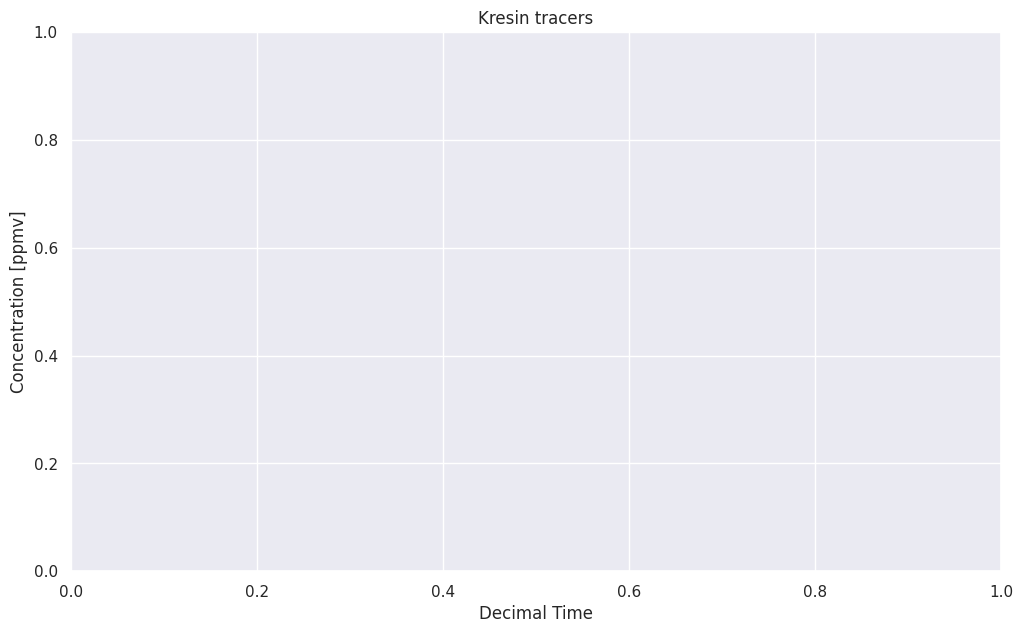

In [6]:
# Initiate concentration and time array:
conc_data = np.zeros((91,70000))-999.99
time_data = np.zeros((91,70000))-999.99

mask_limit = [0.0, 2022.0] # conc, time

file_count = 0

for stati in range(nstat):
    plt.figure(stati, figsize=(12,7))
    plt.title(stations['Name'][stati]+" tracers")
    plt.xlabel("Decimal Time")
    plt.ylabel("Concentration [ppmv]")
    
    for height in stations['Height_ordered'][stati]:
        # Import csv with pandas to dataframe
        df = pd.read_csv(stations['Path_dmi']+stations['File'][file_count], sep=";", header=44, names=dataframe_names)
        
        time_tmp = df['DecimalDate'].values
        conc_tmp = df['co2'].values
        size_tmp = conc_tmp.size
        
        time_data[file_count,:size_tmp] = df['DecimalDate'].values
        conc_data[file_count,:size_tmp] = df['co2'].values
        
        mask = np.array([True if x > mask_limit[0] and y > mask_limit[1] else False for x,y in zip(conc_tmp,time_tmp) ])

        plt.plot(time_tmp[mask], conc_tmp[mask], label=f"height {stations['Height'][file_count]} m")
        
        file_count += 1

    plt.savefig(stations['Code'][stati]+"_tracers")
    plt.close()

In [176]:
# Format testing
a=-0.3
print(f'formatted number: {a:+013.07f}')
print(f'formatted number: {a+356: 013.07f}')
print(f'formatted number: {+4235.56:013.07f}')
print('formatted number: {:013.07f}'.format(3.09405))

formatted number: -0000.3000000
formatted number:  0355.7000000
formatted number: 04235.5600000
formatted number: 00003.0940500


(array([ 2., 15.,  6.,  7.,  4.,  9.,  7.,  3.,  5.,  5.,  6.,  2.,  2.,
         6.,  0.,  3.,  1.,  0.,  1.,  1.,  1.,  1.,  1.,  0.,  0.,  2.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ -5.,   5.,  15.,  25.,  35.,  45.,  55.,  65.,  75.,  85.,  95.,
        105., 115., 125., 135., 145., 155., 165., 175., 185., 195., 205.,
        215., 225., 235., 245., 255., 265., 275., 285., 295., 305., 315.,
        325., 335., 345.]),
 <BarContainer object of 35 artists>)

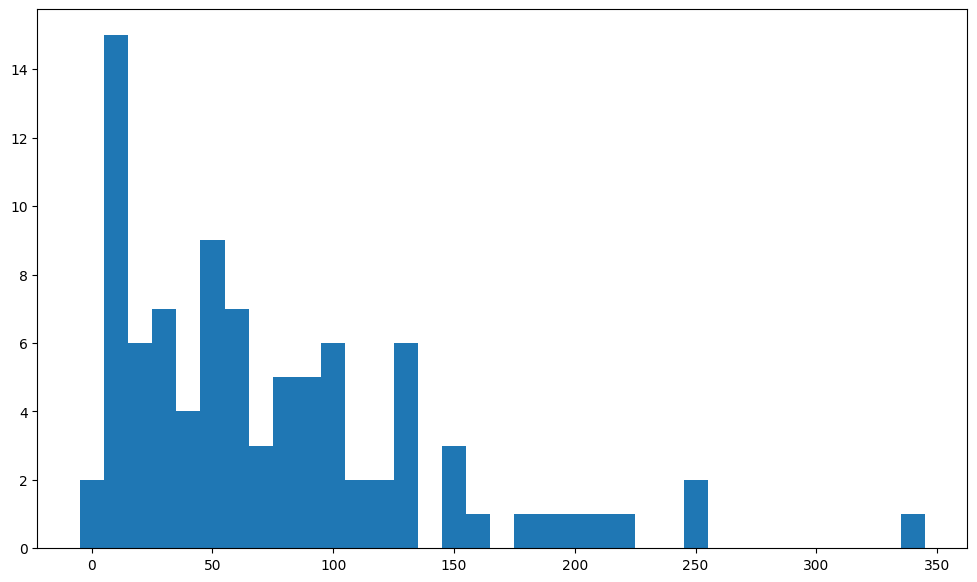

In [30]:
plt.figure(figsize=(12,7))
plt.hist(stations['Height'], bins=np.arange(-5,350,10))

In [ ]:
stations["